========== 1. ИМПОРТ БИБЛИОТЕК ==========

In [1]:
# Библиотеки для работы с данными
import pandas as pd          # Для работы с таблицами (как Excel в Python)
import numpy as np           # Для математических операций

# Библиотеки для визуализации (рисования графиков)
import matplotlib.pyplot as plt  # Основная библиотека для графиков
import seaborn as sns            # Улучшенная визуализация (красивые графики)

# Библиотеки для машинного обучения
from sklearn.model_selection import train_test_split  # Чтобы делить данные на обучение и тест
from sklearn.preprocessing import LabelEncoder        # Чтобы превращать текст (муж/жен) в числа (0/1)

# Метрики для оценки качества моделей
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Импортируем ВСЕ классификаторы
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier
from sklearn.svm import LinearSVC



print("Блок 1: Все библиотеки успешно импортированы")


Блок 1: Все библиотеки успешно импортированы


========== 2. ЗАГРУЗКА ДАННЫХ ==========

In [2]:
from google.colab import files
uploaded = files.upload()

filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)
print(df.head())
print("\n\nИнформация о данных:")
print(df.info())


Saving train.csv to train (4).csv
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            3

========== 3. ПОДГОТОВКА ДАННЫХ ==========

In [3]:
# Удаление ненужных признаков
# PassengerId, Name, Ticket - не влияют на выживание
# Cabin - слишком много пропусков, почти у всех NaN

df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1, inplace=True)
print(df.head())


# Заполнение пропусков
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

print(df.isnull().sum()) # Проверка пропусков

   Survived  Pclass     Sex   Age  SibSp  Parch     Fare Embarked
0         0       3    male  22.0      1      0   7.2500        S
1         1       1  female  38.0      1      0  71.2833        C
2         1       3  female  26.0      0      0   7.9250        S
3         1       1  female  35.0      1      0  53.1000        S
4         0       3    male  35.0      0      0   8.0500        S
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


========== 4. КОДИРОВАНИЕ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ ==========

In [4]:
# Переводим колонки:
# 'Sex' - 'male' в 0, 'female' в 1;
#'Embarked' - 'S' в 0, 'C' в 1, 'Q' в 2

c_sex = LabelEncoder()
c_embarked = LabelEncoder()

df['Sex'] = c_sex.fit_transform(df['Sex'])
df['Embarked'] = c_embarked.fit_transform(df['Embarked'])

print("Данные после кодирования (все числа):")
print(df.head())


Данные после кодирования (все числа):
   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Embarked
0         0       3    1  22.0      1      0   7.2500         2
1         1       1    0  38.0      1      0  71.2833         0
2         1       3    0  26.0      0      0   7.9250         2
3         1       1    0  35.0      1      0  53.1000         2
4         0       3    1  35.0      0      0   8.0500         2


========== 5. РАЗДЕЛЕНИЕ НА X (ПРИЗНАКИ) И y (ЦЕЛЬ) ==========

In [5]:
X = df.drop('Survived', axis=1)
y = df['Survived']

print(f"Размер матрицы признаков X: {X.shape} (строк, колонок)")
print(f"Размер целевой переменной y: {y.shape}")


Размер матрицы признаков X: (891, 7) (строк, колонок)
Размер целевой переменной y: (891,)


========== 6. РАЗДЕЛЕНИЕ НА ОБУЧЕНИЕ И ТЕСТ ==========

In [6]:
# Делим: 80% на обучение, 20% на тест
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Размер обучающей выборки: {X_train.shape[0]} строк")
print(f"Размер тестовой выборки: {X_test.shape[0]} строк")
print(f"Соотношение: {X_train.shape[0]/len(X)*100:.0f}% / {X_test.shape[0]/len(X)*100:.0f}%")


Размер обучающей выборки: 712 строк
Размер тестовой выборки: 179 строк
Соотношение: 80% / 20%


========== 7. СОЗДАНИЕ КЛАССИФИКАТОРОВ ==========

In [7]:
# 1) ФИКТИВНЫЙ КЛАССИФИКАТОР (DUMMY)
# ============================================

# Импортируем нужную библиотеку
from sklearn.dummy import DummyClassifier

# Создаём модель
# strategy='most_frequent' - модель всегда предсказывает самый частый класс (в нашем случае "погиб")
dummy_model = DummyClassifier(strategy='most_frequent')

# Обучаем модель на тренировочных данных
dummy_model.fit(X_train, y_train)

# Делаем предсказание на тестовых данных
y_pred_dummy = dummy_model.predict(X_test)

print("1) Фиктивный классификатор (Dummy) реализован")
print(f"Предсказания: {y_pred_dummy[:10]}...")  # Показываем первые 10 предсказаний



# 2) SVM С ЛИНЕЙНЫМ ЯДРОМ (LINEAR SVC)
# ============================================

# Импортируем нужную библиотеку
from sklearn.svm import LinearSVC

# Создаём модель
# max_iter=1000 - максимальное количество итераций для обучения
# random_state=42 - фиксируем случайность для воспроизводимости
svm_model = LinearSVC(max_iter=1000, random_state=42)

# Обучаем модель
svm_model.fit(X_train, y_train)

# Делаем предсказание
y_pred_svm = svm_model.predict(X_test)

print("\n2) Классификатор SVM с линейным ядром реализован")
print(f"Предсказания: {y_pred_svm[:10]}...")



# 3) КВАДРАТИЧНЫЙ ДИСКРИМИНАНТНЫЙ АНАЛИЗ (QDA)
# ============================================

# Импортируем нужную библиотеку
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

# Создаём модель
qda_model = QuadraticDiscriminantAnalysis()

# Обучаем модель
qda_model.fit(X_train, y_train)

# Делаем предсказание
y_pred_qda = qda_model.predict(X_test)

print("\n3) QDA модель реализована")
print(f"Предсказания: {y_pred_qda[:10]}...")



# 4) K-БЛИЖАЙШИХ СОСЕДЕЙ (KNN)
# ============================================

# Импортируем нужную библиотеку
from sklearn.neighbors import KNeighborsClassifier

# Создаём модель
# n_neighbors=5 - смотрим на 5 ближайших соседей
knn_model = KNeighborsClassifier(n_neighbors=5)

# Обучаем модель
knn_model.fit(X_train, y_train)

# Делаем предсказание
y_pred_knn = knn_model.predict(X_test)

print("\n4) Классификатор KNN реализован")
print(f"Предсказания: {y_pred_knn[:10]}...")



# 5) LightGBM
# ============================================

!pip install lightgbm

# Импортируем нужную библиотеку
from lightgbm import LGBMClassifier

# Создаём модель
# n_estimators=100 - количество деревьев
# learning_rate=0.1 - скорость обучения
# max_depth=3 - глубина деревьев
# verbose=-1 - отключаем вывод логов
# random_state=42 - фиксируем случайность
lightgbm_model = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    verbose=-1,
    random_state=42
)

# Обучаем модель
lightgbm_model.fit(X_train, y_train)

# Делаем предсказание
y_pred_lightgbm = lightgbm_model.predict(X_test)

print("\n5) Классификатор LightGBM реализован")
print(f"Предсказания: {y_pred_lightgbm[:10]}...")



# 6) ДЕРЕВО РЕШЕНИЙ (DECISION TREE)
# ============================================

# Импортируем нужную библиотеку
from sklearn.tree import DecisionTreeClassifier

# Создаём модель
# max_depth=4 - ограничиваем глубину, чтобы дерево не запомнило каждого пассажира
# random_state=42 - фиксируем случайность
decision_tree_model = DecisionTreeClassifier(max_depth=4, random_state=42)

# Обучаем модель
decision_tree_model.fit(X_train, y_train)

# Делаем предсказание
y_pred_decision_tree = decision_tree_model.predict(X_test)

print("\n6) Классификатор Decision Tree реализован")
print(f"Предсказания: {y_pred_decision_tree[:10]}...")



# 7) EXTRA TREES
# ============================================

# Импортируем нужную библиотеку
from sklearn.ensemble import ExtraTreesClassifier

# Создаём модель
# n_estimators=100 - количество деревьев в лесу
# max_depth=3 - максимальная глубина дерева (ограничиваем, чтобы не переобучался)
# random_state=42 - фиксируем случайность
extra_trees_model = ExtraTreesClassifier(n_estimators=100, max_depth=3, random_state=42)

# Обучаем модель
extra_trees_model.fit(X_train, y_train)

# Делаем предсказание
y_pred_extra_trees = extra_trees_model.predict(X_test)

print("\n7) Классификатор Extra Trees реализован")
print(f"Предсказания: {y_pred_extra_trees[:10]}...")



# 8) ГРАДИЕНТНЫЙ БУСТИНГ (GRADIENT BOOSTING)
# ============================================

# Импортируем нужную библиотеку
from sklearn.ensemble import GradientBoostingClassifier

# Создаём модель
# n_estimators=100 - количество деревьев
# learning_rate=0.1 - скорость обучения
# max_depth=3 - глубина деревьев
# random_state=42 - фиксируем случайность
gradient_boosting_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

# Обучаем модель
gradient_boosting_model.fit(X_train, y_train)

# Делаем предсказание
y_pred_gradient_boosting = gradient_boosting_model.predict(X_test)

print("\n8) Классификатор градиентный бустинг реализован")
print(f"Предсказания: {y_pred_gradient_boosting[:10]}...")



# 9) XGBOOST (ЭКСТРЕМАЛЬНЫЙ ГРАДИЕНТНЫЙ БУСТИНГ)
# ============================================

!pip install xgboost

# Импортируем нужную библиотеку
from xgboost import XGBClassifier

# Создаём модель
# n_estimators=100 - количество деревьев
# learning_rate=0.1 - скорость обучения
# max_depth=3 - глубина деревьев
# eval_metric='logloss' - метрика для оценки
# random_state=42 - фиксируем случайность
xgboost_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    eval_metric='logloss',
    random_state=42
)

# Обучаем модель
xgboost_model.fit(X_train, y_train)

# Делаем предсказание
y_pred_xgboost = xgboost_model.predict(X_test)

print("\n9) Классификатор XGBoost реализован")
print(f"Предсказания: {y_pred_xgboost[:10]}...")



# 10) ADA BOOST
# ============================================

# Импортируем нужную библиотеку
from sklearn.ensemble import AdaBoostClassifier

# Создаём модель
# n_estimators=100 - количество деревьев
# learning_rate=0.1 - скорость обучения (меньше = точнее, но дольше)
# random_state=42 - фиксируем случайность
adaboost_model = AdaBoostClassifier(n_estimators=100, learning_rate=0.1, random_state=42)

# Обучаем модель
adaboost_model.fit(X_train, y_train)

# Делаем предсказание
y_pred_adaboost = adaboost_model.predict(X_test)

print("\n10) Классификатор Ada Boost реализован")
print(f"Предсказания: {y_pred_adaboost[:10]}...")



# 11) CATBOOST
# ============================================

!pip install catboost

# Импортируем нужную библиотеку
from catboost import CatBoostClassifier

# Создаём модель
# iterations=100 - количество деревьев (аналог n_estimators)
# learning_rate=0.1 - скорость обучения
# depth=3 - глубина деревьев
# verbose=False - отключаем вывод логов
# random_state=42 - фиксируем случайность
catboost_model = CatBoostClassifier(
    iterations=100,
    learning_rate=0.1,
    depth=3,
    verbose=False,
    random_state=42
)
# Обучаем модель
catboost_model.fit(X_train, y_train)

# Делаем предсказание
y_pred_catboost = catboost_model.predict(X_test)

print("\n11) Классификатор CatBoost реализован")
print(f"Предсказания: {y_pred_catboost[:10]}...")



1) Фиктивный классификатор (Dummy) реализован
Предсказания: [0 0 0 0 0 0 0 0 0 0]...

2) Классификатор SVM с линейным ядром реализован
Предсказания: [0 0 0 1 1 1 1 0 1 1]...

3) QDA модель реализована
Предсказания: [0 0 0 1 1 1 1 0 1 1]...

4) Классификатор KNN реализован
Предсказания: [0 0 0 0 0 1 1 0 1 1]...

5) Классификатор LightGBM реализован
Предсказания: [0 0 0 1 1 1 1 0 1 1]...

6) Классификатор Decision Tree реализован
Предсказания: [0 0 0 1 1 1 1 0 1 1]...

7) Классификатор Extra Trees реализован
Предсказания: [0 0 0 1 1 1 1 0 1 1]...

8) Классификатор градиентный бустинг реализован
Предсказания: [0 0 0 1 1 1 1 0 1 1]...

9) Классификатор XGBoost реализован
Предсказания: [0 0 0 1 1 1 1 0 1 1]...

10) Классификатор Ada Boost реализован
Предсказания: [0 0 0 1 1 1 1 0 1 1]...

11) Классификатор CatBoost реализован
Предсказания: [0 0 0 1 1 1 1 0 1 1]...


========== 8. СБОР ВСЕХ ПРЕДСКАЗАНИЙ ==========

In [8]:
# Собираем все предсказания в словарь для удобного сравнения
predictions = {
    'Dummy': y_pred_dummy,
    'Linear SVM': y_pred_svm,
    'QDA': y_pred_qda,
    'KNN': y_pred_knn,
    'LightGBM': y_pred_lightgbm,
    'Decision Tree': y_pred_decision_tree,
    'Extra Trees': y_pred_extra_trees,
    'Gradient Boosting': y_pred_gradient_boosting,
    'XGBoost': y_pred_xgboost,
    'AdaBoost': y_pred_adaboost,
    'CatBoost': y_pred_catboost
}

print("\nВсе предсказания собраны в словарь")
print(f"Количество моделей: {len(predictions)}")



Все предсказания собраны в словарь
Количество моделей: 11


========== 9. СРАВНЕНИЕ МЕТРИК КАЧЕСТВА ==========

========== 9.1 Расчет метрик качества для моделей

In [9]:
# Импортируем метрики
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Создаём список для хранения результатов
results = []

print("РАСЧЁТ МЕТРИК ДЛЯ ВСЕХ МОДЕЛЕЙ")

# Проходим по каждой модели
for name, y_pred in predictions.items():
    # Считаем метрики
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    # Добавляем в список
    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    })

    # Выводим результат для текущей модели
    print(f"\n{name}:")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1-Score:  {f1:.4f}")



РАСЧЁТ МЕТРИК ДЛЯ ВСЕХ МОДЕЛЕЙ

Dummy:
  Accuracy:  0.5866
  Precision: 0.0000
  Recall:    0.0000
  F1-Score:  0.0000

Linear SVM:
  Accuracy:  0.7933
  Precision: 0.7681
  Recall:    0.7162
  F1-Score:  0.7413

QDA:
  Accuracy:  0.8212
  Precision: 0.7917
  Recall:    0.7703
  F1-Score:  0.7808

KNN:
  Accuracy:  0.7039
  Precision: 0.6842
  Recall:    0.5270
  F1-Score:  0.5954

LightGBM:
  Accuracy:  0.8045
  Precision: 0.7910
  Recall:    0.7162
  F1-Score:  0.7518

Decision Tree:
  Accuracy:  0.7989
  Precision: 0.8393
  Recall:    0.6351
  F1-Score:  0.7231

Extra Trees:
  Accuracy:  0.7989
  Precision: 0.7969
  Recall:    0.6892
  F1-Score:  0.7391

Gradient Boosting:
  Accuracy:  0.8101
  Precision: 0.8125
  Recall:    0.7027
  F1-Score:  0.7536

XGBoost:
  Accuracy:  0.8156
  Precision: 0.8254
  Recall:    0.7027
  F1-Score:  0.7591

AdaBoost:
  Accuracy:  0.7933
  Precision: 0.7761
  Recall:    0.7027
  F1-Score:  0.7376

CatBoost:
  Accuracy:  0.8045
  Precision: 0.8095
  R

========== 9.2 Общая таблица метрик качества

In [10]:
# Превращаем список в таблицу (DataFrame)
results_df = pd.DataFrame(results)

# Сортируем по Accuracy
results_df_sorted = results_df.sort_values('Accuracy', ascending=False)
print("ОБЩАЯ ТАБЛИЦА МЕТРИК\n")
print(results_df_sorted.to_string(float_format=lambda x: f"{x:.4f}"))


ОБЩАЯ ТАБЛИЦА МЕТРИК

                Model  Accuracy  Precision  Recall  F1-Score
2                 QDA    0.8212     0.7917  0.7703    0.7808
8             XGBoost    0.8156     0.8254  0.7027    0.7591
7   Gradient Boosting    0.8101     0.8125  0.7027    0.7536
4            LightGBM    0.8045     0.7910  0.7162    0.7518
10           CatBoost    0.8045     0.8095  0.6892    0.7445
5       Decision Tree    0.7989     0.8393  0.6351    0.7231
6         Extra Trees    0.7989     0.7969  0.6892    0.7391
9            AdaBoost    0.7933     0.7761  0.7027    0.7376
1          Linear SVM    0.7933     0.7681  0.7162    0.7413
3                 KNN    0.7039     0.6842  0.5270    0.5954
0               Dummy    0.5866     0.0000  0.0000    0.0000


========== 10. ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ ==========

========== 10.1 Сравнение метрик качества классификаторов

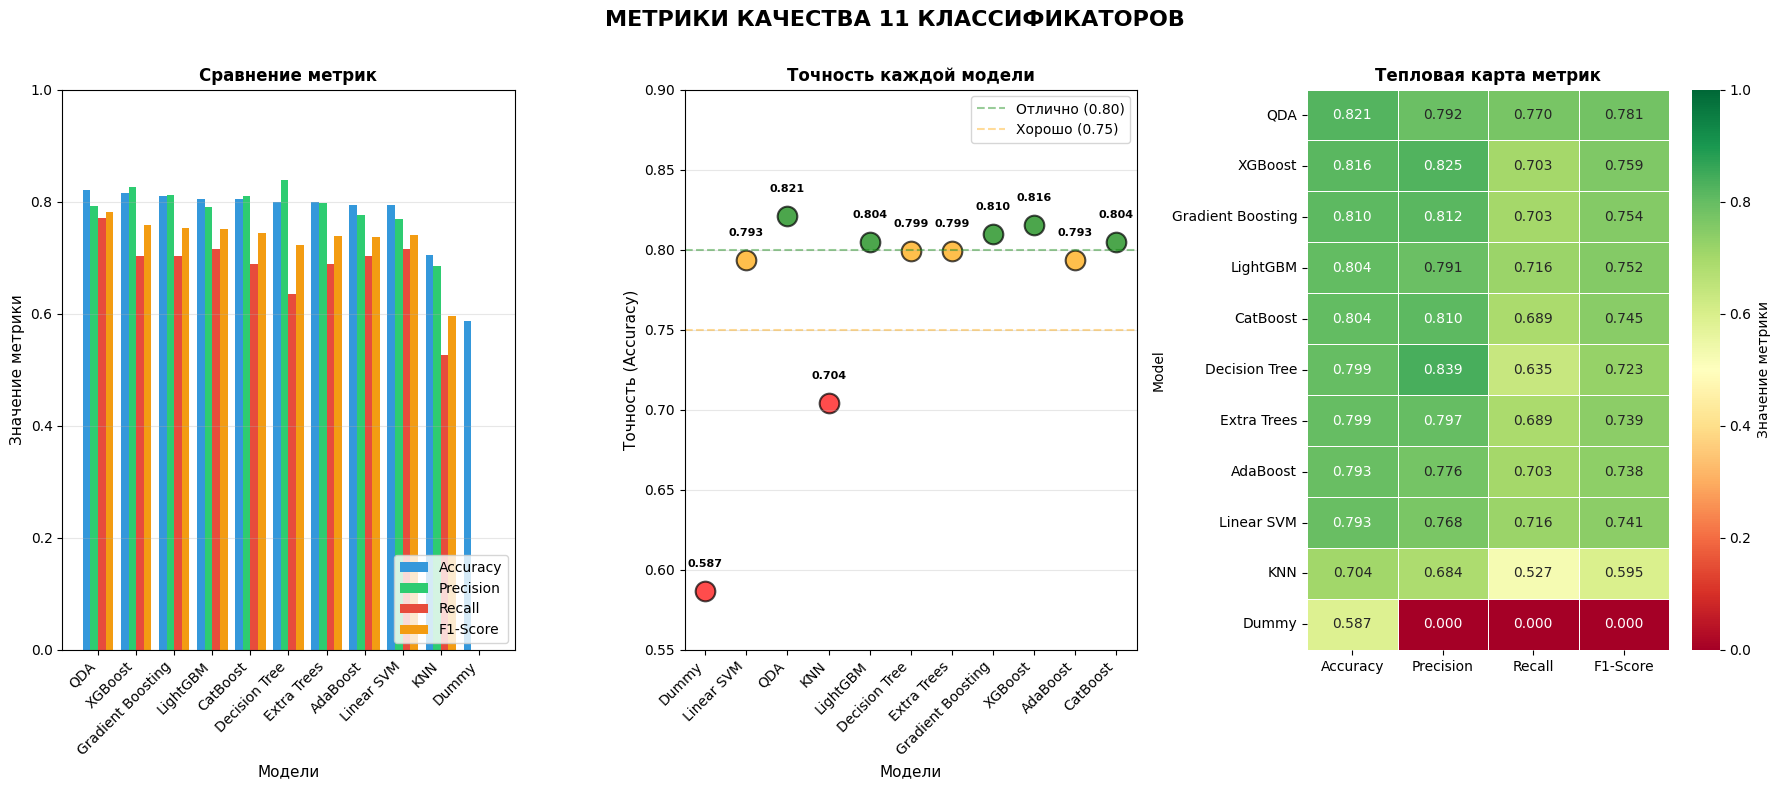


Все графики сохранены в 'titanic_full_comparison.png'


In [11]:
# Создаём фигуру с 3 графиками
fig = plt.figure(figsize=(18, 8))

# ===== ГРАФИК 1: СТОЛБЧАТАЯ ДИАГРАММА =====
ax1 = plt.subplot(1, 3, 1)
x = np.arange(len(results_df_sorted['Model']))
width = 0.2

ax1.bar(x - 1.5*width, results_df_sorted['Accuracy'], width, label='Accuracy', color='#3498db')
ax1.bar(x - 0.5*width, results_df_sorted['Precision'], width, label='Precision', color='#2ecc71')
ax1.bar(x + 0.5*width, results_df_sorted['Recall'], width, label='Recall', color='#e74c3c')
ax1.bar(x + 1.5*width, results_df_sorted['F1-Score'], width, label='F1-Score', color='#f39c12')

ax1.set_xlabel('Модели', fontsize=11)
ax1.set_ylabel('Значение метрики', fontsize=11)
ax1.set_title('Сравнение метрик', fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(results_df_sorted['Model'], rotation=45, ha='right', fontsize=10)
ax1.set_ylim(0, 1.0)
ax1.legend(loc='lower right', fontsize=10)
ax1.grid(axis='y', alpha=0.3)



# ===== ГРАФИК 2: ТОЧЕЧНАЯ ДИАГРАММА  =====
ax3 = plt.subplot(1, 3, 2)

# Собираем точности
accuracies = []
model_names = []
for name, y_pred in predictions.items():
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)
    model_names.append(name)

# Рисуем точки
for i, (name, acc) in enumerate(zip(model_names, accuracies)):
    if acc >= 0.80:
        color = 'green'
    elif acc >= 0.75:
        color = 'orange'
    else:
        color = 'red'

    ax3.scatter(i, acc, s=200, c=color, alpha=0.7, edgecolors='black', linewidth=1.5)
    ax3.text(i, acc + 0.015, f'{acc:.3f}', ha='center', fontsize=8, fontweight='bold')

ax3.set_xlabel('Модели', fontsize=11)
ax3.set_ylabel('Точность (Accuracy)', fontsize=11)
ax3.set_title('Точность каждой модели', fontsize=12, fontweight='bold')
ax3.set_xticks(range(len(model_names)))
ax3.set_xticklabels(model_names, rotation=45, ha='right', fontsize=10)
ax3.set_ylim(0.55, 0.90)
ax3.grid(axis='y', alpha=0.3)
ax3.axhline(y=0.80, color='green', linestyle='--', alpha=0.4, label='Отлично (0.80)')
ax3.axhline(y=0.75, color='orange', linestyle='--', alpha=0.4, label='Хорошо (0.75)')
ax3.legend(fontsize=10)


# ===== ГРАФИК 3: ТЕПЛОВАЯ КАРТА =====
ax2 = plt.subplot(1, 3, 3)
heatmap_data = results_df_sorted.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1-Score']]
sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='RdYlGn',
            cbar_kws={'label': 'Значение метрики'},
            linewidths=0.5, vmin=0, vmax=1, ax=ax2)
ax2.set_title('Тепловая карта метрик', fontsize=12, fontweight='bold')


# Общий заголовок
plt.suptitle('МЕТРИКИ КАЧЕСТВА 11 КЛАССИФИКАТОРОВ\n',
             fontsize=16, fontweight='bold')

plt.tight_layout()
plt.savefig('titanic_full_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nВсе графики сохранены в 'titanic_full_comparison.png'")


========== 10.2 Визуализация предсказаний

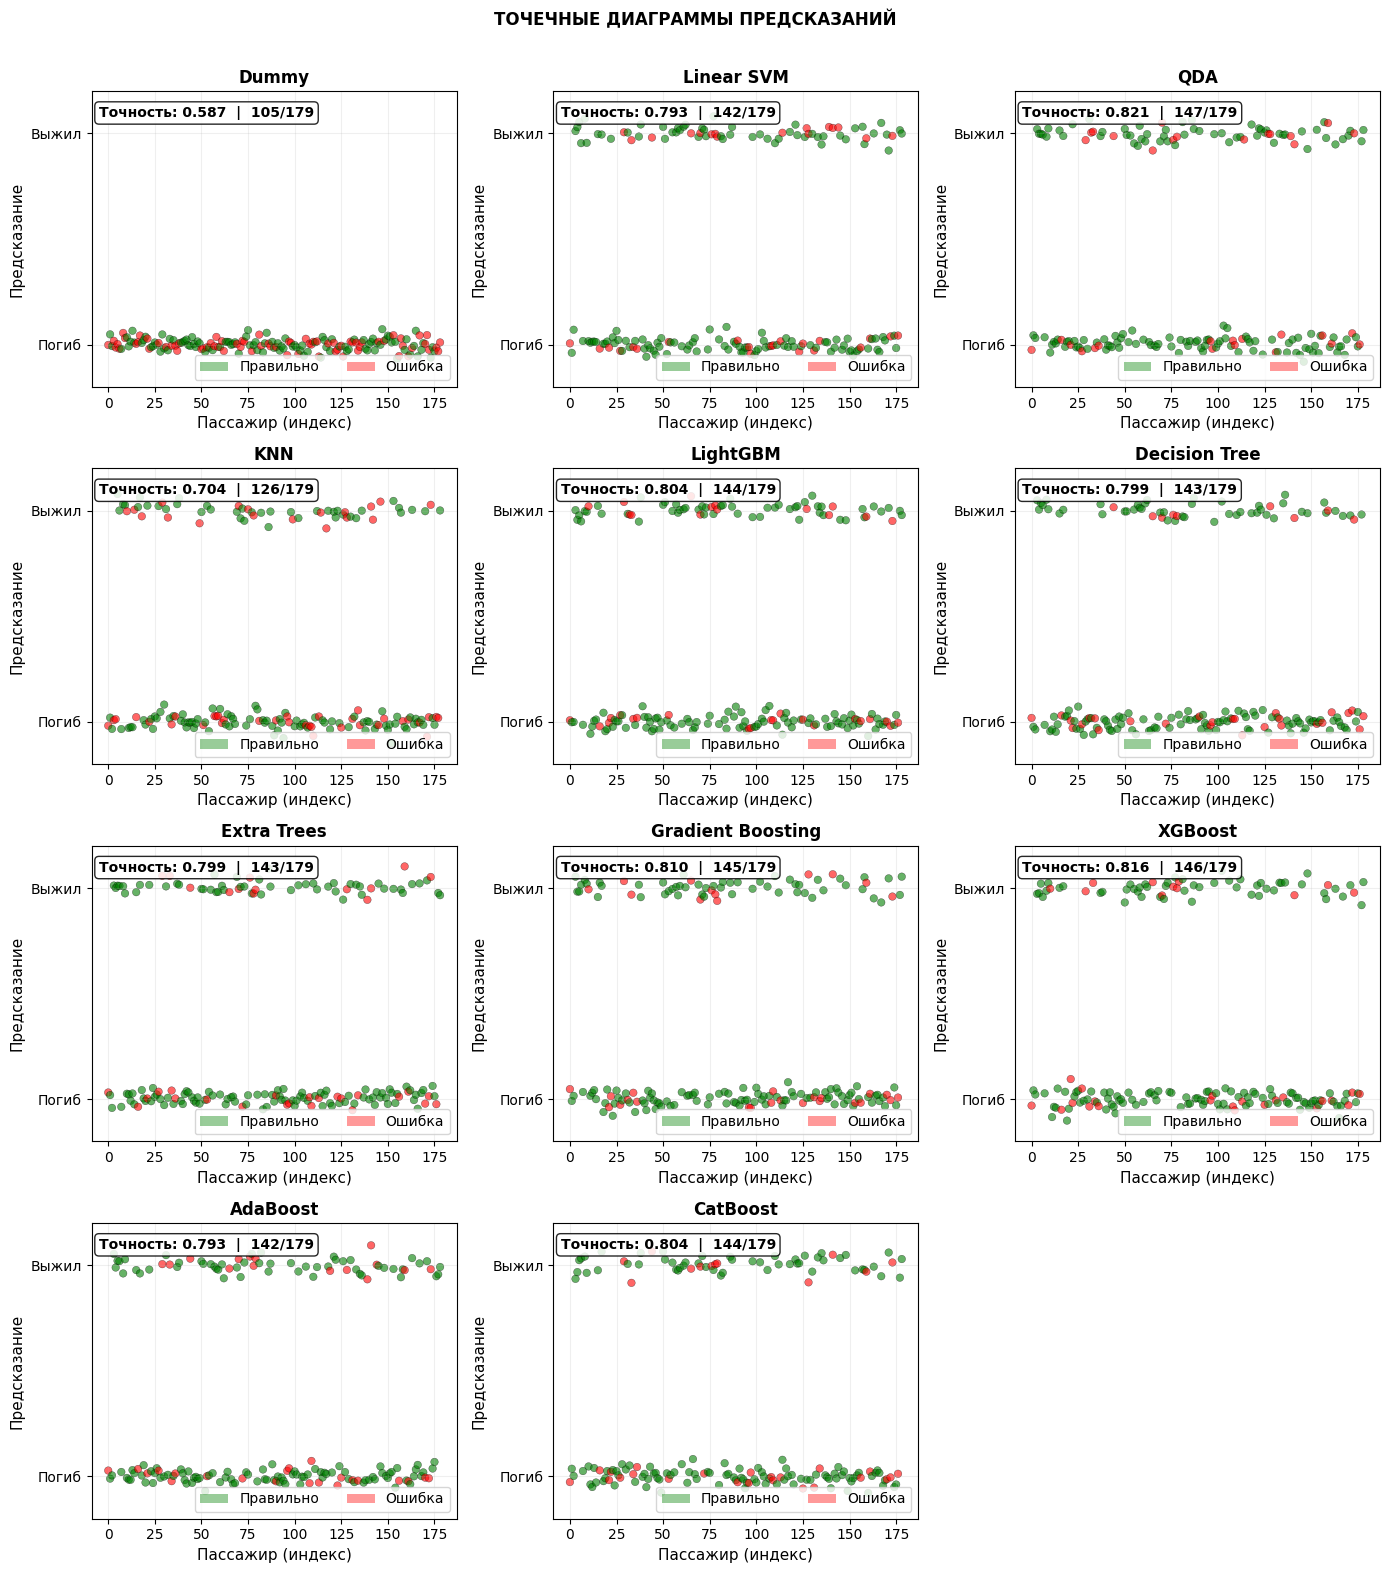


Точечные диаграммы с линией тренда сохранены как 'titanic_scatter_with_trend.png'


In [12]:
# ТОЧЕЧНЫЕ ДИАГРАММЫ

# Расчёт количества строк и колонок
n_models = len(predictions)
n_cols = 3  # По 3 графика в ряд
n_rows = (n_models + n_cols - 1) // n_cols

# Создаём фигуру с графиками
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))

if n_rows == 1:
    axes = axes.reshape(1, -1)

# Проходим по каждой модели
for idx, (name, y_pred) in enumerate(predictions.items()):
    row = idx // n_cols
    col = idx % n_cols
    ax = axes[row, col]

    # Данные для точечной диаграммы
    x_points = np.arange(len(y_pred))
    y_points = y_pred

    # Цвета: зелёный = правильно, красный = ошибка
    colors = ['green' if pred == true else 'red' for pred, true in zip(y_pred, y_test)]

    # Добавляем шум, чтобы точки не накладывались
    jitter = np.random.normal(0, 0.03, len(y_pred))
    y_jitter = y_points + jitter

    # Рисуем точечную диаграмму
    ax.scatter(x_points, y_jitter, c=colors, alpha=0.6, s=30, edgecolors='black', linewidth=0.3)


    # Настройки графика
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlabel('Пассажир (индекс)', fontsize=11)
    ax.set_ylabel('Предсказание', fontsize=11)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['Погиб', 'Выжил'], fontsize=10)
    ax.set_ylim(-0.2, 1.2)
    ax.grid(True, alpha=0.2)

    # Информация о точности
    acc = accuracy_score(y_test, y_pred)
    correct = sum(y_pred == y_test)
    total = len(y_pred)

    info_text = f'Точность: {acc:.3f}  |  {correct}/{total}'
    ax.text(0.02, 0.95, info_text,
            transform=ax.transAxes,
            fontsize=10,
            verticalalignment='top',
            fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))

    # Легенда
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='green', alpha=0.4, label='Правильно'),
        Patch(facecolor='red', alpha=0.4, label='Ошибка'),
    ]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=10, ncol=3)

# Убираем пустые графики
for idx in range(len(predictions), n_rows * n_cols):
    row = idx // n_cols
    col = idx % n_cols
    axes[row, col].set_visible(False)

# Общий заголовок
plt.suptitle('ТОЧЕЧНЫЕ ДИАГРАММЫ ПРЕДСКАЗАНИЙ\n\n',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('titanic_scatter_with_trend.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nТочечные диаграммы с линией тренда сохранены как 'titanic_scatter_with_trend.png'")

========== 11. АНАЛИЗ ВАЖНОСТИ ПРИЗНАКОВ ==========

========== 11.1 Определение классификаторов, имеющих параметр важности признаков

In [13]:
# Список всех моделей
all_models = [
    ('Dummy', dummy_model),
    ('Linear SVM', svm_model),
    ('QDA', qda_model),
    ('KNN', knn_model),
    ('Extra Trees', extra_trees_model),
    ('Decision Tree', decision_tree_model),
    ('AdaBoost', adaboost_model),
    ('Gradient Boosting', gradient_boosting_model),
    ('XGBoost', xgboost_model),
    ('LightGBM', lightgbm_model),
    ('CatBoost', catboost_model)
]

# Проверка наличия feature_importances_
models_with_importance = {}
models_without = []

for name, model in all_models:
    if hasattr(model, 'feature_importances_'):
        models_with_importance[name] = model
    else:
        models_without.append(name)


print("\nМодели без feature_importances:")
for name in models_without:
    print(f"  - {name}")

print("\nМодели с feature_importances:")
for name in models_with_importance:
    print(f"  - {name}")



Модели без feature_importances:
  - Dummy
  - Linear SVM
  - QDA
  - KNN

Модели с feature_importances:
  - Extra Trees
  - Decision Tree
  - AdaBoost
  - Gradient Boosting
  - XGBoost
  - LightGBM
  - CatBoost


========== 11.2 Анализ важности признаков для каждой модели

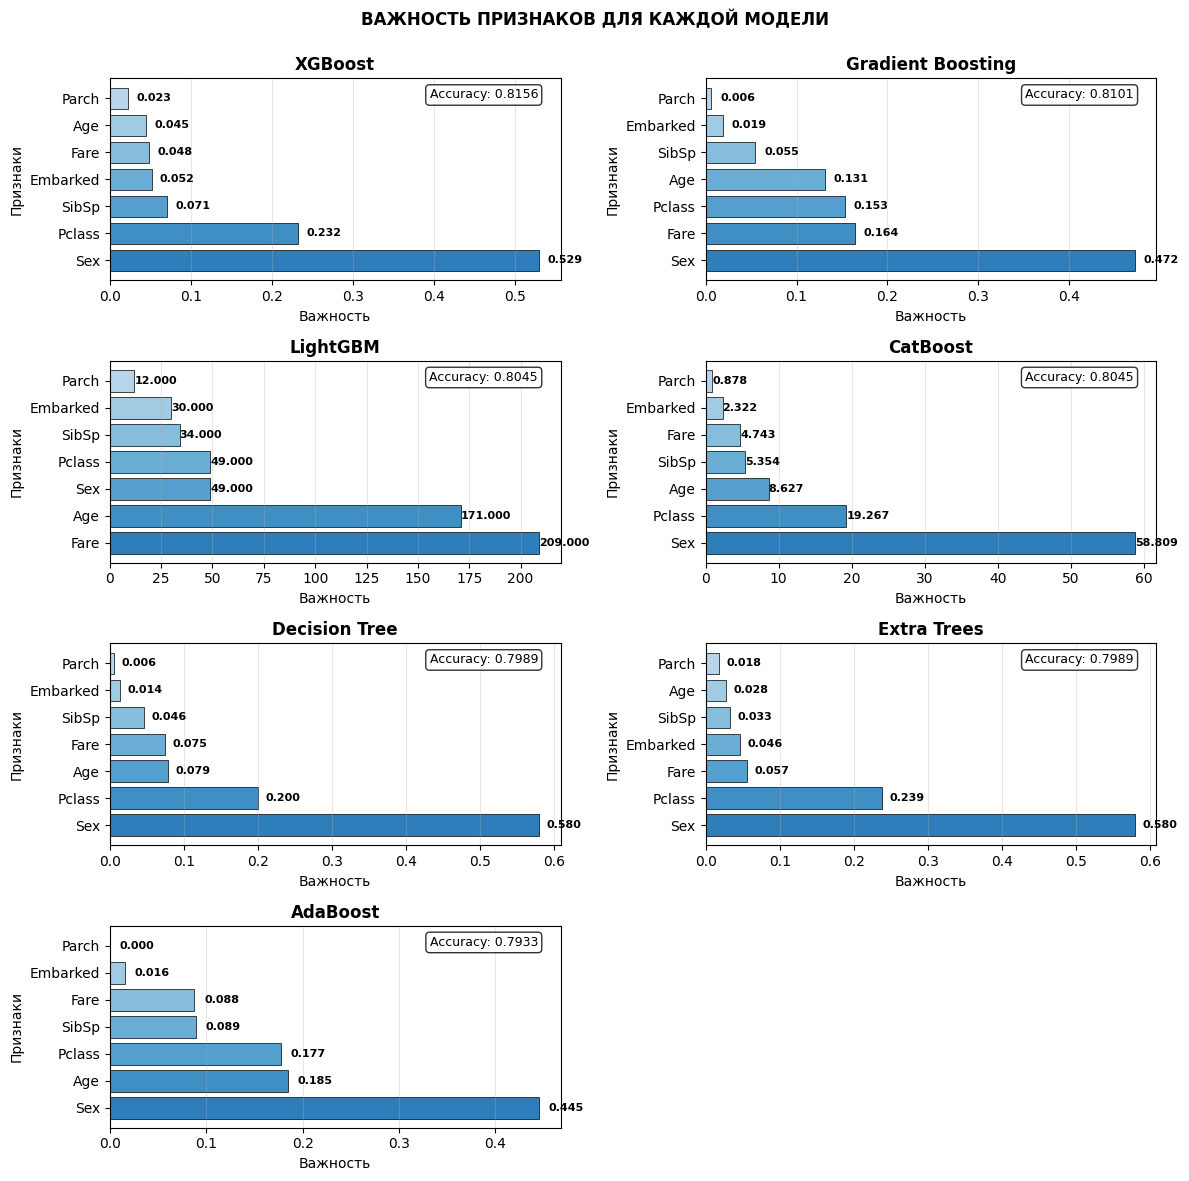


Графики важности признаков сохранены как 'feature_importance_all_models.png'


In [14]:
models_with_importance = [
    ('XGBoost', xgboost_model),
    ('Gradient Boosting', gradient_boosting_model),
    ('LightGBM', lightgbm_model),
    ('CatBoost', catboost_model),
    ('Decision Tree', decision_tree_model),
    ('Extra Trees', extra_trees_model),
    ('AdaBoost', adaboost_model)
]

# Количество моделей
n_models = len(models_with_importance)

# По 2 графика в ряд
n_cols = 2
n_rows = (n_models + n_cols - 1) // n_cols

# Создаём фигуру с графиками
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 3 * n_rows))

# Если получился одномерный массив, превращаем в двумерный
if n_rows == 1:
    axes = axes.reshape(1, -1)

# Проходим по каждой модели
for idx, (name, model) in enumerate(models_with_importance):
    row = idx // n_cols
    col = idx % n_cols
    ax = axes[row, col]

    # Проверяем, есть ли у модели метод feature_importances_
    if hasattr(model, 'feature_importances_'):
        # Получаем важность признаков
        importances = model.feature_importances_
        feature_names = X.columns

        # Сортируем по убыванию важности
        sorted_idx = np.argsort(importances)[::-1]
        sorted_importances = importances[sorted_idx]
        sorted_features = feature_names[sorted_idx]

        # Рисуем горизонтальную столбчатую диаграмму
        colors = plt.cm.Blues(np.linspace(0.3, 0.7, len(sorted_features)))[::-1]
        ax.barh(sorted_features, sorted_importances, color=colors, edgecolor='black', linewidth=0.5)

        # Настройки графика
        ax.set_xlabel('Важность', fontsize=10)
        ax.set_ylabel('Признаки', fontsize=10)
        ax.set_title(f'{name}', fontsize=12, fontweight='bold')
        ax.grid(axis='x', alpha=0.3)

        # Добавляем значения важности на столбцы
        for i, (feature, importance) in enumerate(zip(sorted_features, sorted_importances)):
            ax.text(importance + 0.01, i, f'{importance:.3f}',
                    va='center', fontsize=8, fontweight='bold')

        # Получаем точность модели из таблицы
        acc = results_df_sorted[results_df_sorted['Model'] == name]['Accuracy'].values[0]
        ax.text(0.95, 0.95, f'Accuracy: {acc:.4f}',
                transform=ax.transAxes,
                fontsize=9,
                verticalalignment='top',
                horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    else:
        ax.text(0.5, 0.5, f'У модели {name}\nнет feature_importances_',
                ha='center', va='center', fontsize=12, transform=ax.transAxes)
        ax.set_title(name, fontsize=12, fontweight='bold')

# Убираем пустые графики
for idx in range(len(models_with_importance), n_rows * n_cols):
    row = idx // n_cols
    col = idx % n_cols
    axes[row, col].set_visible(False)

# Общий заголовок
plt.suptitle('ВАЖНОСТЬ ПРИЗНАКОВ ДЛЯ КАЖДОЙ МОДЕЛИ\n',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance_all_models.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nГрафики важности признаков сохранены как 'feature_importance_all_models.png'")

========== 11.3 Общий анализ важности признаков

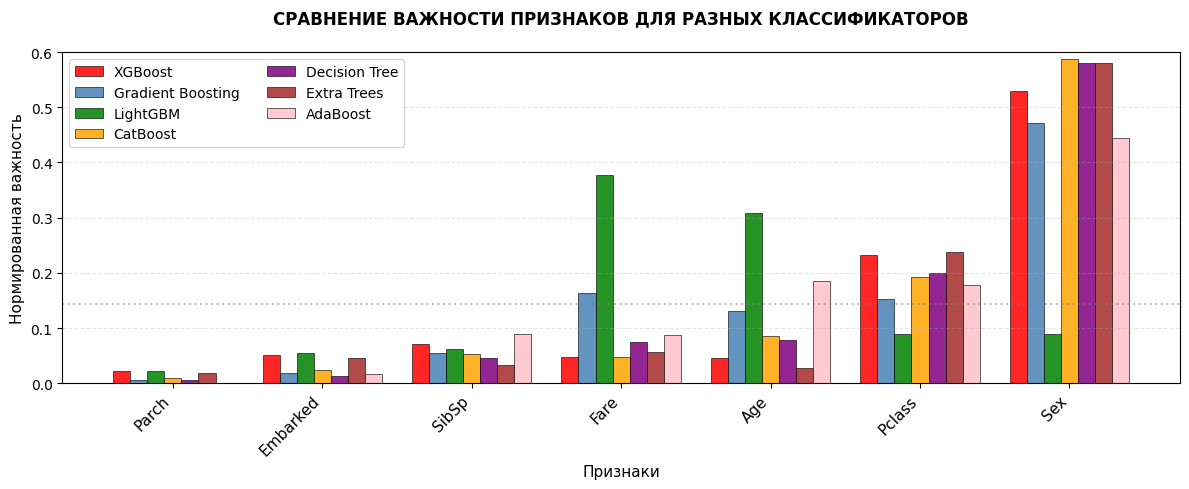


График сохранён как 'feature_importance_all_models.png'

ТАБЛИЦА ВАЖНОСТИ ПРИЗНАКОВ (НОРМИРОВАННАЯ)
          XGBoost  Gradient Boosting  LightGBM  CatBoost  Decision Tree  Extra Trees  AdaBoost  Средняя
Sex        0.5293             0.4720    0.0884    0.5881         0.5796       0.5796    0.4453   0.4689
Pclass     0.2320             0.1531    0.0884    0.1927         0.2005       0.2386    0.1774   0.1832
Age        0.0449             0.1311    0.3087    0.0863         0.0789       0.0277    0.1846   0.1232
Fare       0.0483             0.1641    0.3773    0.0474         0.0752       0.0565    0.0877   0.1224
SibSp      0.0709             0.0548    0.0614    0.0535         0.0461       0.0334    0.0891   0.0584
Embarked   0.0517             0.0186    0.0542    0.0232         0.0139       0.0462    0.0159   0.0320
Parch      0.0228             0.0063    0.0217    0.0088         0.0059       0.0180    0.0000   0.0119

ТОП-3 ВАЖНЫХ ПРИЗНАКА
1. Sex        : средняя важность = 0.4689
2.

In [15]:
# ПОСТРОЕНИЕ ОБЩЕЙ СТОЛБЧАТОЙ ДИАГРАММЫ

# Собираем важности для всех моделей
importance_dict = {}
feature_names = X.columns

for name, model in models_with_importance:
    importances = model.feature_importances_
    # Нормируем к сумме - для корректного сравнения
    importances_norm = importances / importances.sum()
    importance_dict[name] = importances_norm

# Создаём DataFrame
importance_df = pd.DataFrame(importance_dict, index=feature_names)

# Сортируем признаки по средней важности (от самого важного к наименее важному)
importance_df['mean'] = importance_df.mean(axis=1)
importance_df = importance_df.sort_values('mean', ascending=True)
importance_df = importance_df.drop('mean', axis=1)

# Настройки для групповой столбчатой диаграммы
n_features = len(importance_df.index)
n_models = len(importance_df.columns)

# Ширина одного столбца
width = 0.8 / n_models

# Позиции для групп столбцов
x = np.arange(n_features)

# Цветовая палитра для моделей
colors = ['red', 'steelblue', 'green', 'orange', 'purple',
          'brown', 'pink', 'cyan', 'magenta', 'lime', 'teal']

# Создаём фигуру
plt.figure(figsize=(12, 5))

# Рисуем столбцы для каждой модели
for i, model_name in enumerate(importance_df.columns):
    offset = (i - n_models/2) * width + width/2
    plt.bar(x + offset, importance_df[model_name],
            width, label=model_name,
            color=colors[i % len(colors)],
            edgecolor='black', linewidth=0.5,
            alpha=0.85)

# Настройки графика
plt.xlabel('Признаки', fontsize=11)
plt.ylabel('Нормированная важность', fontsize=11)
plt.title('СРАВНЕНИЕ ВАЖНОСТИ ПРИЗНАКОВ ДЛЯ РАЗНЫХ КЛАССИФИКАТОРОВ\n',
          fontsize=12, fontweight='bold')
plt.xticks(x, importance_df.index, fontsize=11, rotation=45, ha='right')
plt.ylim(0, 0.6)
plt.legend(loc='upper left', fontsize=10, ncol=2)
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Добавляем горизонтальную линию для среднего значения
plt.axhline(y=1/len(feature_names), color='gray', linestyle=':', alpha=0.5,
            label=f'Средняя важность ({1/len(feature_names):.3f})')

plt.tight_layout()
plt.savefig('feature_importance_all_models.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nГрафик сохранён как 'feature_importance_all_models.png'")

# ------------------------------------------------------------
# ВЫВОД ТАБЛИЦЫ С ЧИСЛЕННЫМИ ЗНАЧЕНИЯМИ
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("ТАБЛИЦА ВАЖНОСТИ ПРИЗНАКОВ (НОРМИРОВАННАЯ)")
print("=" * 80)

# Добавляем столбец со средней важностью
importance_df_display = importance_df.copy()
importance_df_display['Средняя'] = importance_df_display.mean(axis=1)
importance_df_display = importance_df_display.sort_values('Средняя', ascending=False)

print(importance_df_display.round(4).to_string())
print("=" * 80)

# ------------------------------------------------------------
# ТОП-3 САМЫХ ВАЖНЫХ ПРИЗНАКА (ПО СРЕДНЕМУ)
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("ТОП-3 ВАЖНЫХ ПРИЗНАКА")
print("=" * 80)

importance_df_mean = importance_df.mean(axis=1).sort_values(ascending=False)
top3 = importance_df_mean.head(3)

for idx, (feature, importance) in enumerate(top3.items(), 1):
    print(f"{idx}. {feature:10s} : средняя важность = {importance:.4f}")
